# Power Spectrum

In [34]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import torch 

import sys
from pathlib import Path

# set parent directory to sys.path for imports
NOTEBOOK_DIR = Path.cwd().resolve()
PARENT_DIR = NOTEBOOK_DIR.parents[2]
if str(PARENT_DIR) not in sys.path:
    sys.path.insert(0, str(PARENT_DIR))
    print(f"Parent directory added to sys.path: ...\\{PARENT_DIR.name}")
else:
    print(f"Parent directory already in sys.path: ...\\{PARENT_DIR.name}")


# set dataset directory path
DATA_TEST_PATH = PARENT_DIR / "data" / "test"
print("Dataset directory used:", f"...\\{PARENT_DIR.name}\\{DATA_TEST_PATH.relative_to(PARENT_DIR)}")

from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch

Parent directory already in sys.path: ...\STL-Dev
Dataset directory used: ...\STL-Dev\data\test


In [35]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


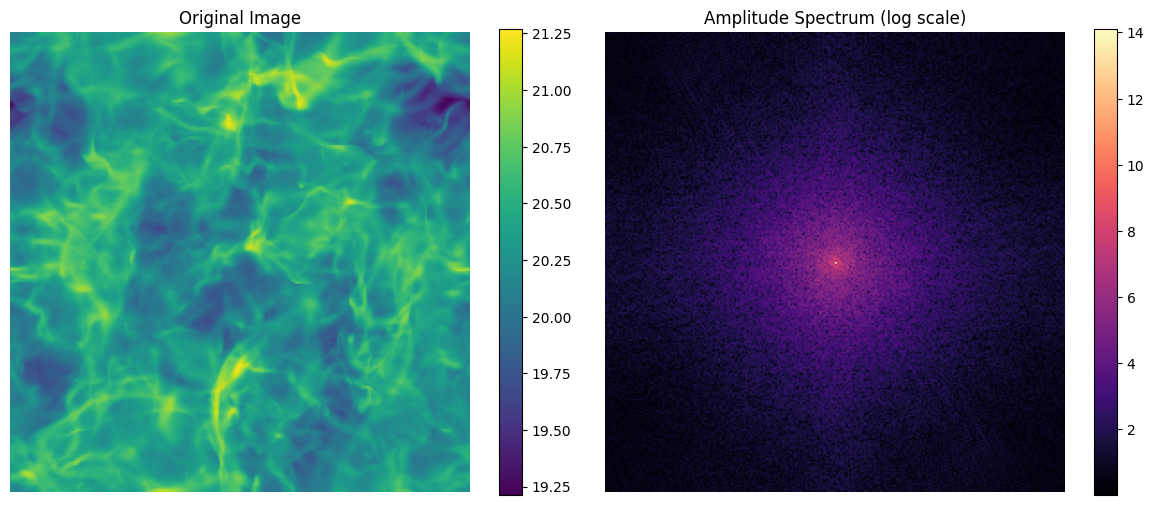

In [36]:
# Load periodic data
im = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[0]
im = torch.from_numpy(im).float()

# Compute FFT amplitude spectrum
im_fft = torch.fft.fftshift(torch.fft.fft2(im))
im_fft_amp = torch.abs(im_fft)

# Plot original data and amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(im.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

In [37]:
# Instantiate FFT dataclasse
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_no_pbc = STL_2D_FFT_Torch(array=im, pbc=False)

# Get PS operator
cs_op = data.get_CS_op()

C:\Users\Danie\Bureau\STL-Dev\STL_main\STL_2D_FFT_Torch.py:1270: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  k_vals_tensor = torch.tensor(k_vals)


In [38]:
print("Minimal frequency:", cs_op.min_freq)
print("Maximal frequency (Nyquist):", cs_op.max_freq)
print("Estimated crop borders (for each bin mask):", cs_op.crop_borders)

Minimal frequency: 0.015625
Maximal frequency (Nyquist): 0.5
Estimated crop borders (for each bin mask): tensor([111,  91,  73,  60,  49,  39,  32,  26,  21,  17,  13,  11,  11,   9,
          8,  10])


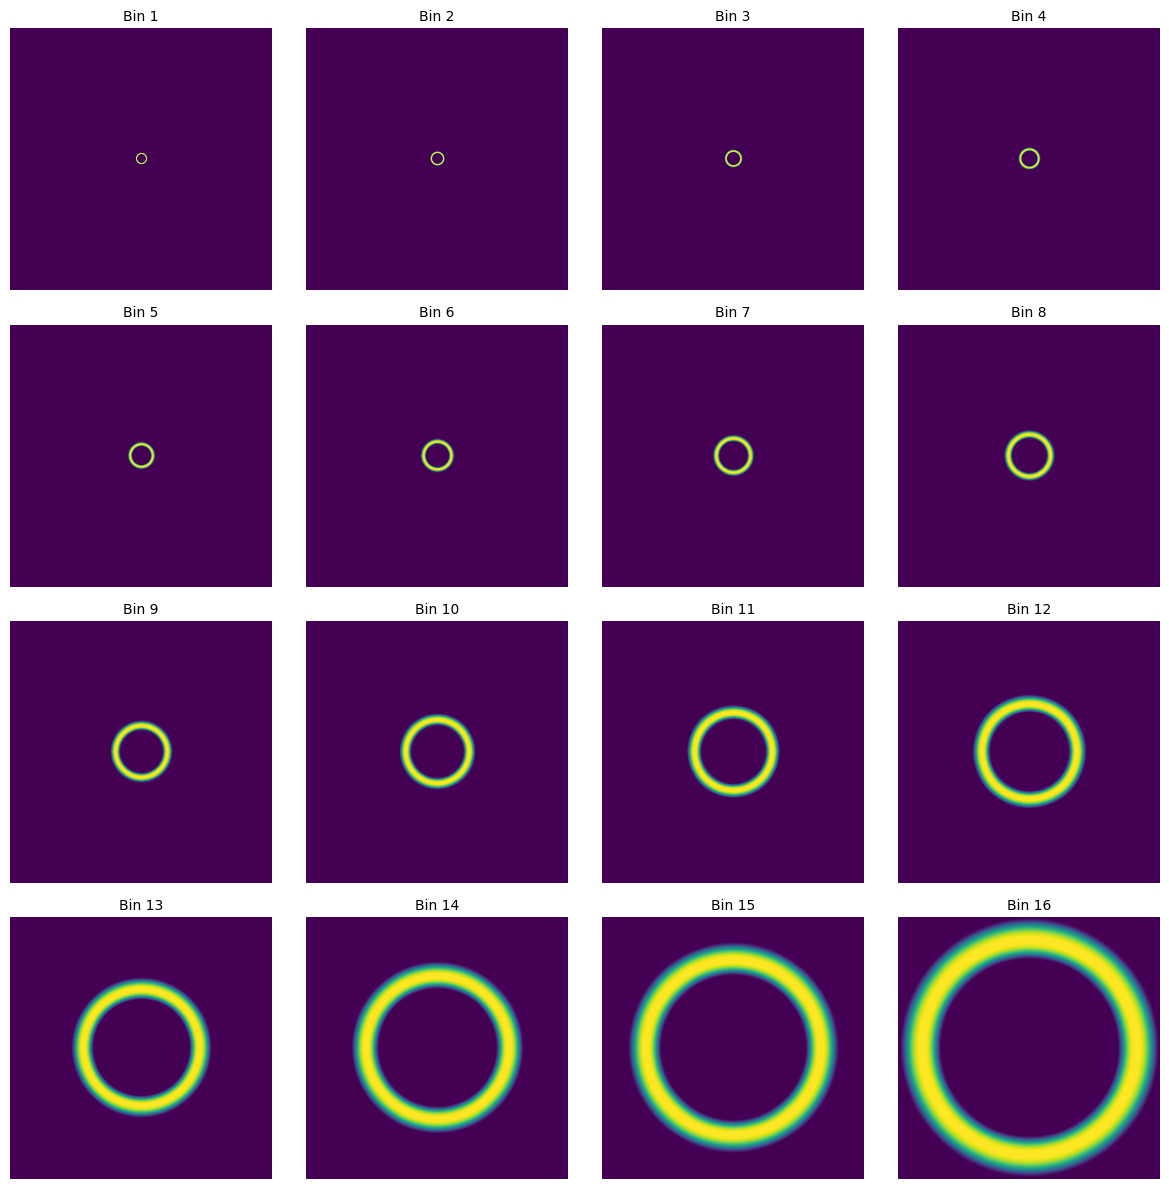

In [39]:
# Plot bin masks in fourier space (rings with gaussian radial profile)
plt.figure(figsize=(12, 12)) 

n_rows, n_cols = 4, 4       

for i in range(cs_op.bin_masks.shape[0]):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(cs_op.bin_masks[i].cpu(), cmap='viridis', origin='lower')
    plt.title(f"Bin {i+1}", fontsize=10)
    plt.axis('off')  

plt.tight_layout()
plt.show()

In [16]:
print(cs_op.bin_masks.shape)

torch.Size([16, 256, 256])


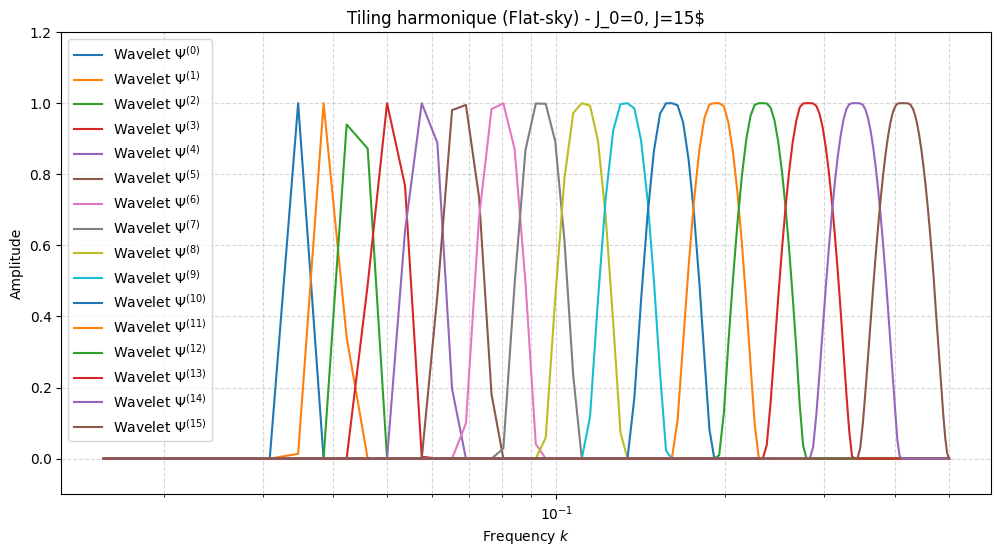

In [40]:
# 1D radial profile of the bin masks + LP check
n_bins, N, M = cs_op.bin_masks.shape
radial_profile_bin_masks = cs_op.bin_masks[:, N//2, M//2:] # [n_bins, M//2]
k_vals = torch.linspace(cs_op.min_freq, cs_op.max_freq, M//2)
plt.figure(figsize=(12, 6))
for i, j in enumerate(range(n_bins)):
    plt.plot(k_vals, radial_profile_bin_masks[i], label=f'Wavelet $\Psi^{{({j})}}$')

plt.xscale("log")
plt.ylim(-0.1, 1.2)
plt.title(f"Tiling harmonique (Flat-sky) - J_0={0}, J={n_bins-1}$")
plt.xlabel("Frequency $k$")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In the figure with a linear frequency scale, we observe a degradation in the quality of the wavelets at low frequencies. This can be explained by the image resolution.

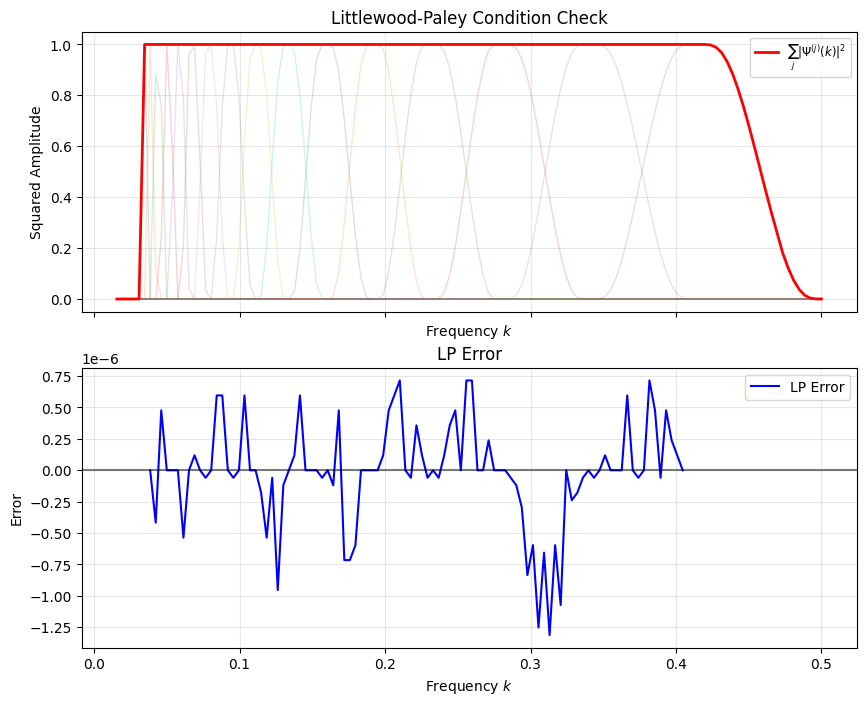

In [60]:
lp_sum = torch.sum(torch.abs(radial_profile_bin_masks)**2, dim=0) # [M//2]
lp_error = lp_sum - 1.0

# Plot the sum of the squared amplitudes of the bin masks to check the Littlewood-Paley condition
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for i in range(n_bins):
    ax1.plot(k_vals, radial_profile_bin_masks[i]**2, alpha=0.2, lw=1)
ax1.plot(k_vals, lp_sum, 'r', lw=2, label='$\sum_j |\Psi^{(j)}(k)|^2$')
ax1.set_ylabel('Squared Amplitude')
ax1.set_xlabel('Frequency $k$')
ax1.set_title('Littlewood-Paley Condition Check')
ax1.legend(loc='upper right', fontsize='small')
ax1.grid(True, alpha=0.3)

# Constrain between the first and last wavelet frequencies centers (domain where the LP condition should hold)
mask = (k_vals > cs_op.min_freq * cs_op.lam ** 4) & (k_vals <= cs_op.max_freq / cs_op.lam)
ax2.plot(k_vals[mask], lp_error[mask], 'b', label='LP Error')
ax2.axhline(0, color='black', linestyle='-', alpha=0.5)
ax2.set_ylabel('Error')
ax2.set_xlabel('Frequency $k$')
ax2.set_title('LP Error')
ax2.legend()
ax2.grid(True, alpha=0.3)


Text(0.5, 1.0, 'Energy Recovery Ratio in Fourier Space')

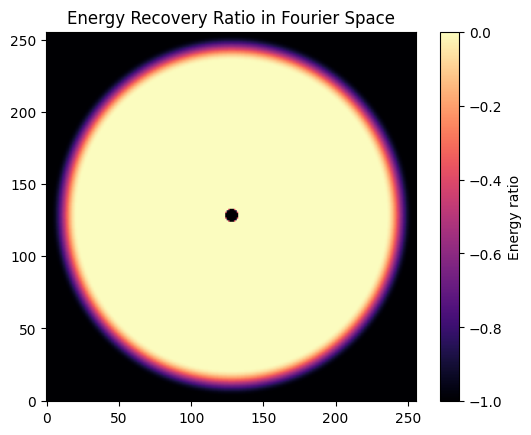

In [64]:
# LP check of 2D bin masks 
lp_sum_2d = torch.sum(torch.abs(cs_op.bin_masks)**2, dim=0) # [N, M]
lp_error_2d = lp_sum_2d - 1.0

plt.imshow(
    lp_error_2d.cpu().numpy(),
    origin='lower',
    cmap='magma'
)

plt.colorbar(label="Energy ratio")
plt.title("Energy Recovery Ratio in Fourier Space")

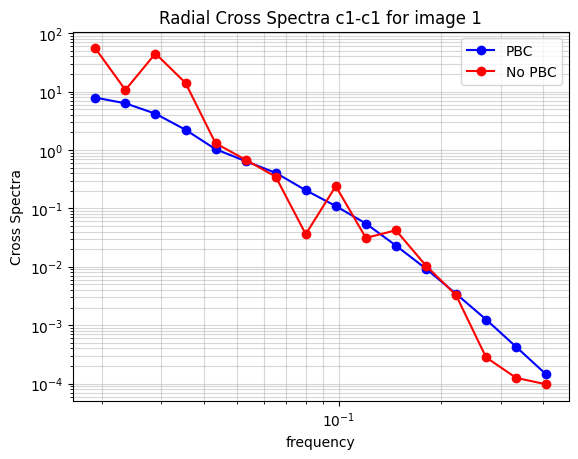

In [8]:
# Compute power spectrum for both periodic and non-periodic data
cross_spectrum = cs_op.apply(data)
cross_spectrum_no_pbc = cs_op.apply(data_no_pbc, get_crop_border_size_method="flexible_crop")

# Compare power spectra (should be aligned for the same periodic data, even if specified as non periodic)
cs_op.plot_cross_spectrum(cross_spectrum.real, b=0, c1=0, c2=0, label="PBC", color="b")
cs_op.plot_cross_spectrum(cross_spectrum_no_pbc.abs(), b=0, c1=0, c2=0, label="No PBC", color="r")

Great, it fits pretty well!

Let's now compare power spectrum between pbc and real non pbc data

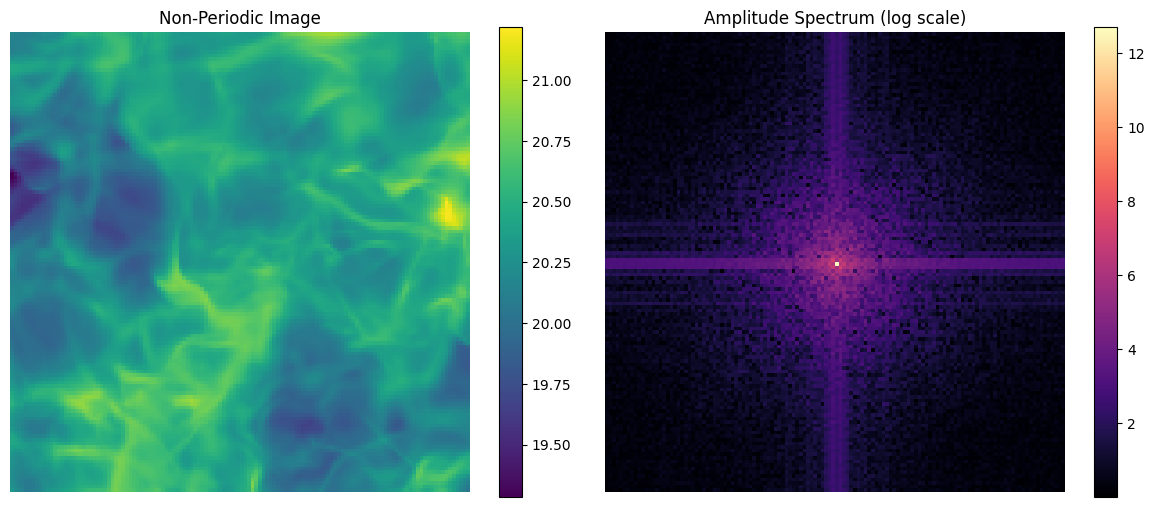

In [9]:
# Extract non periodic portion (128x128) from the original data
im_no_pbc = im[0:128, 0:128]

# Compute FFT amplitude spectrum of non periodic data
im_no_pbc_fft = torch.fft.fftshift(torch.fft.fft2(im_no_pbc))
im_no_pbc_fft_amp = torch.abs(im_no_pbc_fft)

# Plot non periodic data and its amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Non-Periodic Image")
plt.imshow(im_no_pbc.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_no_pbc_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

The spectral leakage cross is strong here because we crop the original image at the level of a structure, which makes the extracted image highly non-periodic.

In [10]:
# Instantiate FFT dataclasses for both periodic and non-periodic data
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_cropped_no_pbc = STL_2D_FFT_Torch(array=im_no_pbc, pbc=False)

# Get PS operator (different because build on different data shapes)
cs_op = data.get_CS_op()
cs_op_no_pbc = data_cropped_no_pbc.get_CS_op()

# Compute power spectrum for both periodic and non-periodic data
cross_spectrum = cs_op.apply(data)[0, 0, :]
cross_spectrum_no_pbc = cs_op_no_pbc.apply(data_cropped_no_pbc, get_crop_border_size_method="largest_crop")[0, 0, :]

In [11]:
print(cross_spectrum.shape)
print(cross_spectrum_no_pbc.shape)

torch.Size([1, 16])
torch.Size([1, 8])


C:\Users\Danie\AppData\Roaming\Python\Python311\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Danie\AppData\Roaming\Python\Python311\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


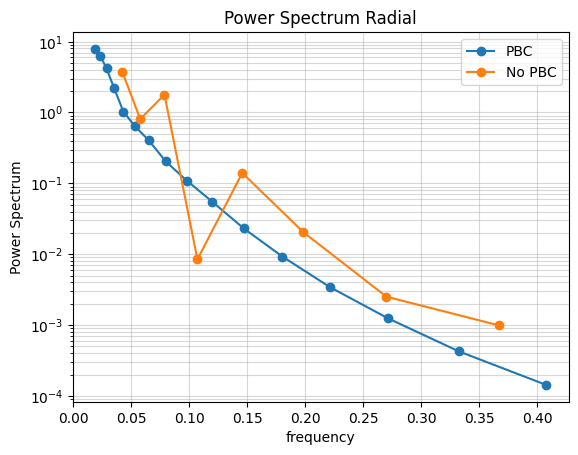

In [12]:
# Plot power spectra for both periodic and non-periodic data
plt.plot(cs_op.bin_centers, cross_spectrum[0], "-", marker="o", label="PBC")
plt.plot(cs_op_no_pbc.bin_centers, cross_spectrum_no_pbc[0].abs(), "-", marker="o", label="No PBC")

plt.yscale("log")
plt.xlabel("frequency")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum Radial")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

The two power spectra are estimated from images of different sizes and periodicities. They do not perfectly overlap due to sampling variance in the non-periodic cropped image, different bin intervals (and therefore not identical steps), and the cropping process.

In [13]:
im = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[:3] # Take 3 channels for cross spectrum

# Instantiate FFT dataclasse
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_no_pbc = STL_2D_FFT_Torch(array=im, pbc=False)

# Get PS operator
cs_op = data.get_CS_op()

# Compute power spectrum for both periodic and non-periodic data
compute_cross_spectrum_matrix = torch.tensor([[True, True, True],[False, True, True],[False, False, True]])
cross_spectrum = cs_op.apply(data, compute_cross_spectrum_matrix)
cross_spectrum_no_pbc = cs_op.apply(data_no_pbc, compute_cross_spectrum_matrix, get_crop_border_size_method="largest_crop")

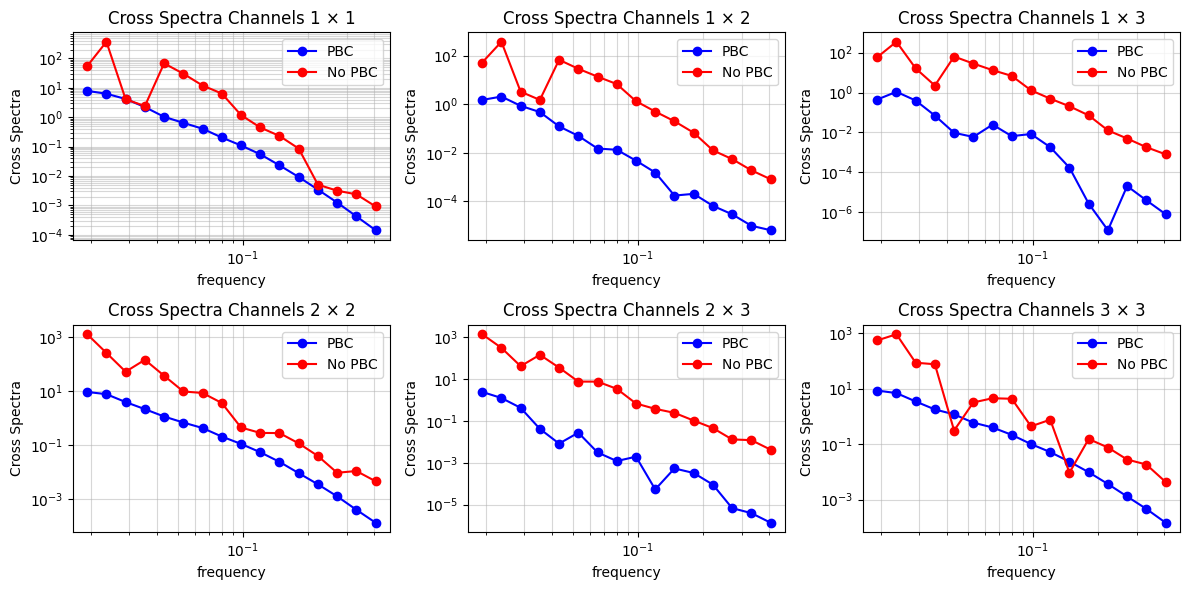

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

pairs = [(0,0), (0,1), (0,2), (1,1), (1,2), (2,2)]

for i, (c1, c2) in enumerate(pairs):
    plt.sca(axes[i])

    cs_op.plot_cross_spectrum(
        cross_spectrum.abs(), b=0, c1=c1, c2=c2,
        label="PBC", color="b"
    )

    cs_op.plot_cross_spectrum(
        cross_spectrum_no_pbc.abs(), b=0, c1=c1, c2=c2,
        label="No PBC", color="r"
    )

    plt.title(f"Cross Spectra Channels {c1+1} × {c2+1}")
    plt.legend()

plt.tight_layout()
plt.show()